# 实验二：梯度下降法动态模拟

## 知识背景回顾

在上一节实验中，我们直观地理解了什么是梯度。现在，我们将学习如何**利用梯度**来寻找函数的最小值。

在我们使用的《最优化方法与机器学习》教材 **4.2节** 中，正式介绍了 **梯度下降法 (Gradient Descent Method)**。这是最基础、也是应用最广泛的优化算法之一。它的核心思想非常符合直觉：**想最快地下山，就要沿着最陡峭的方向走**。

这个“最陡峭的下降方向”就是**负梯度方向** `-∇f(x)`。

因此，梯度下降法的迭代公式就是我们 **4.1节** 学到的通用公式的一个特例，其中搜索方向 `d^k` 被指定为负梯度 `-∇f(x^k)`：

$$
\mathbf{x}^{k+1} = \mathbf{x}^k - \alpha \nabla f(\mathbf{x}^k)
$$

其中，$\alpha$ 就是我们之前提到的**步长**，在机器学习领域，它更常被称为**学习率 (Learning Rate)**。

## 实验说明

本次实验设计两个模块来帮助理解梯度下降算法的工作原理与参数设计对其的影响。

### 模块一：交互式探索

在模块一，你可以自由设置参数，观察梯度下降在不同“地形”上的表现。

1.  **选择函数**：我们为你准备了三个经典的优化测试函数，你可以通过下拉菜单选择：
    * **二次碗型函数**：一个狭长的“碗”，只有一个全局最小值。
    * **多谷函数**：拥有多个局部/全局最小值的复杂地形。
    * **Rosenbrock函数**：一个带有狭长、弯曲“山谷”的著名“病态”函数，对优化算法极具挑战性。
2.  **设置参数**：你可以通过滑杆自由调节 **初始点 (x₀, y₀)**、**学习率 α** 以及 **迭代次数**。
3.  **观察路径**：程序会根据你选择的函数和参数，实时绘制出梯度下降的完整路径。

### 模块二：预设案例分析

为了让你更系统地学习，我们为你准备了几个精心设计的“经典案例”，展示了梯度下降法最重要的几种行为模式。每个案例都配有图示和原理解释。你将在这里看到：

* 学习率过小、合适、过大甚至导致发散时，算法路径分别是什么样子。
* 对于复杂的非凸函数，不同的初始点是如何“决定”算法最终命运的。
* 为什么有些函数（如Rosenbrock函数）会让梯度下降法举步维艰。

请先在模块一中充分探索，然后带着你的发现和疑问，到模块二中寻找答案和总结。

In [1]:
# 导入所有需要的库
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown, FloatSlider, IntSlider, VBox, HBox, interactive_output
import warnings
plt.rcParams['font.sans-serif'] = ['SimHei']  # 正确显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号
# 忽略一些可能出现的计算警告
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning) 

# --- 数据准备：定义所有函数及其梯度与推荐参数 ---

def bowl_function(x, y): return x**2 + 10 * y**2
def bowl_grad(x, y): return np.array([2 * x, 20 * y])

def multi_valley_function(x, y):
    term1 = -3 * np.exp(-((x - 1.5)**2 + (y - 1.5)**2) / 2)
    term2 = -2 * np.exp(-((x + 1.5)**2 + (y + 1.5)**2) / 3)
    return term1 + term2

def multi_valley_grad(x, y):
    dx1 = -3 * np.exp(-((x - 1.5)**2 + (y - 1.5)**2) / 2) * (-(x - 1.5))
    dy1 = -3 * np.exp(-((x - 1.5)**2 + (y - 1.5)**2) / 2) * (-(y - 1.5))
    dx2 = -2 * np.exp(-((x + 1.5)**2 + (y + 1.5)**2) / 3) * (-(2/3)*(x + 1.5))
    dy2 = -2 * np.exp(-((x + 1.5)**2 + (y + 1.5)**2) / 3) * (-(2/3)*(y + 1.5))
    return np.array([dx1 + dx2, dy1 + dy2])

def rosenbrock_function(x, y): return (1 - x)**2 + 100 * (y - x**2)**2
def rosenbrock_grad(x, y):
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

# ******** 修改点：为每个函数配置专属的参数范围 ********
functions = {
    "二次碗型函数": {
        "func": bowl_function, "grad": bowl_grad, "x_range": (-5, 5), "y_range": (-2, 2), "levels": 20,
        "x_start_params": {'min': -5.0, 'max': 5.0, 'value': 4.0},
        "y_start_params": {'min': -2.0, 'max': 2.0, 'value': 1.5},
        "lr_params": {'min': 0.001, 'max': 0.11, 'step': 0.001, 'value': 0.08, 'readout_format': '.3f'}
    },
    "多谷函数": {
        "func": multi_valley_function, "grad": multi_valley_grad, "x_range": (-4, 4), "y_range": (-4, 4), "levels": 15,
        "x_start_params": {'min': -4.0, 'max': 4.0, 'value': 1.0},
        "y_start_params": {'min': -4.0, 'max': 4.0, 'value': 2.5},
        "lr_params": {'min': 0.01, 'max': 1.0, 'step': 0.01, 'value': 0.3, 'readout_format': '.2f'}
    },
    "Rosenbrock函数": {
        "func": rosenbrock_function, "grad": rosenbrock_grad, "x_range": (-2, 2), "y_range": (-1, 3), "levels": 50,
        "x_start_params": {'min': -2.0, 'max': 2.0, 'value': -1.5},
        "y_start_params": {'min': -1.0, 'max': 3.0, 'value': 2.5},
        "lr_params": {'min': 0.0001, 'max': 0.0040, 'step': 0.0002, 'value': 0.001, 'readout_format': '.4f'}
    }
}
# ******************************************************

def run_gradient_descent(grad_func, start_point, learning_rate, n_iterations):
    path = [start_point]
    point = np.array(start_point, dtype=float)
    for _ in range(n_iterations):
        grad = grad_func(point[0], point[1])
        point = point - learning_rate * grad
        path.append(point.copy())
    return np.array(path)

In [ ]:
# --- 模块一：交互式探索 (采用新的UI布局和动态更新逻辑) ---

# 1. 定义绘图函数 (保持不变)
def interactive_plotter(func_name, x_start, y_start, learning_rate, iterations):
    info = functions[func_name]
    func, grad_func, x_range, y_range = info["func"], info["grad"], info["x_range"], info["y_range"]
    
    x = np.linspace(x_range[0], x_range[1], 200)
    y = np.linspace(y_range[0], y_range[1], 200)
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)
    
    start_point = (x_start, y_start)
    path = run_gradient_descent(grad_func, start_point, learning_rate, iterations)
    
    plt.figure(figsize=(10, 8))
    plt.contour(X, Y, Z, levels=info["levels"], cmap='viridis')
    plt.plot(path[:, 0], path[:, 1], '-o', color='red', markersize=3, label='优化路径')
    plt.plot(start_point[0], start_point[1], 'go', markersize=10, label='初始点')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'函数: {func_name} | 学习率 α: {learning_rate} | 迭代次数: {iterations}')
    plt.legend()
    plt.grid(True)
    plt.xlim(x_range)
    plt.ylim(y_range)
    plt.show()

# 2. 创建所有UI控件
func_name_w = Dropdown(options=functions.keys(), description='选择函数:')
x_start_w = FloatSlider(description='初始点 x₀:')
y_start_w = FloatSlider(description='初始点 y₀:')
lr_w = FloatSlider(description='学习率 α:')
iterations_w = IntSlider(min=1, max=500, step=1, value=100, description='迭代次数:')

# 3. 定义滑杆更新函数
def update_sliders(*args):
    params = functions[func_name_w.value]
    for key, slider in {'x_start_params': x_start_w, 'y_start_params': y_start_w, 'lr_params': lr_w}.items():
        for attr, value in params[key].items():
            setattr(slider, attr, value)

# 4. 绑定更新函数到下拉菜单
func_name_w.observe(update_sliders, 'value')

# 5. 初始化滑杆状态
update_sliders()

# 6. 将UI控件和绘图函数连接起来
interactive_app = interactive_output(interactive_plotter, {
    'func_name': func_name_w, 'x_start': x_start_w, 'y_start': y_start_w, 
    'learning_rate': lr_w, 'iterations': iterations_w
})

# 7. 显示UI界面和图形
display(VBox([
    HBox([func_name_w, iterations_w]), 
    HBox([x_start_w, y_start_w]),
    lr_w,
    interactive_app
]))

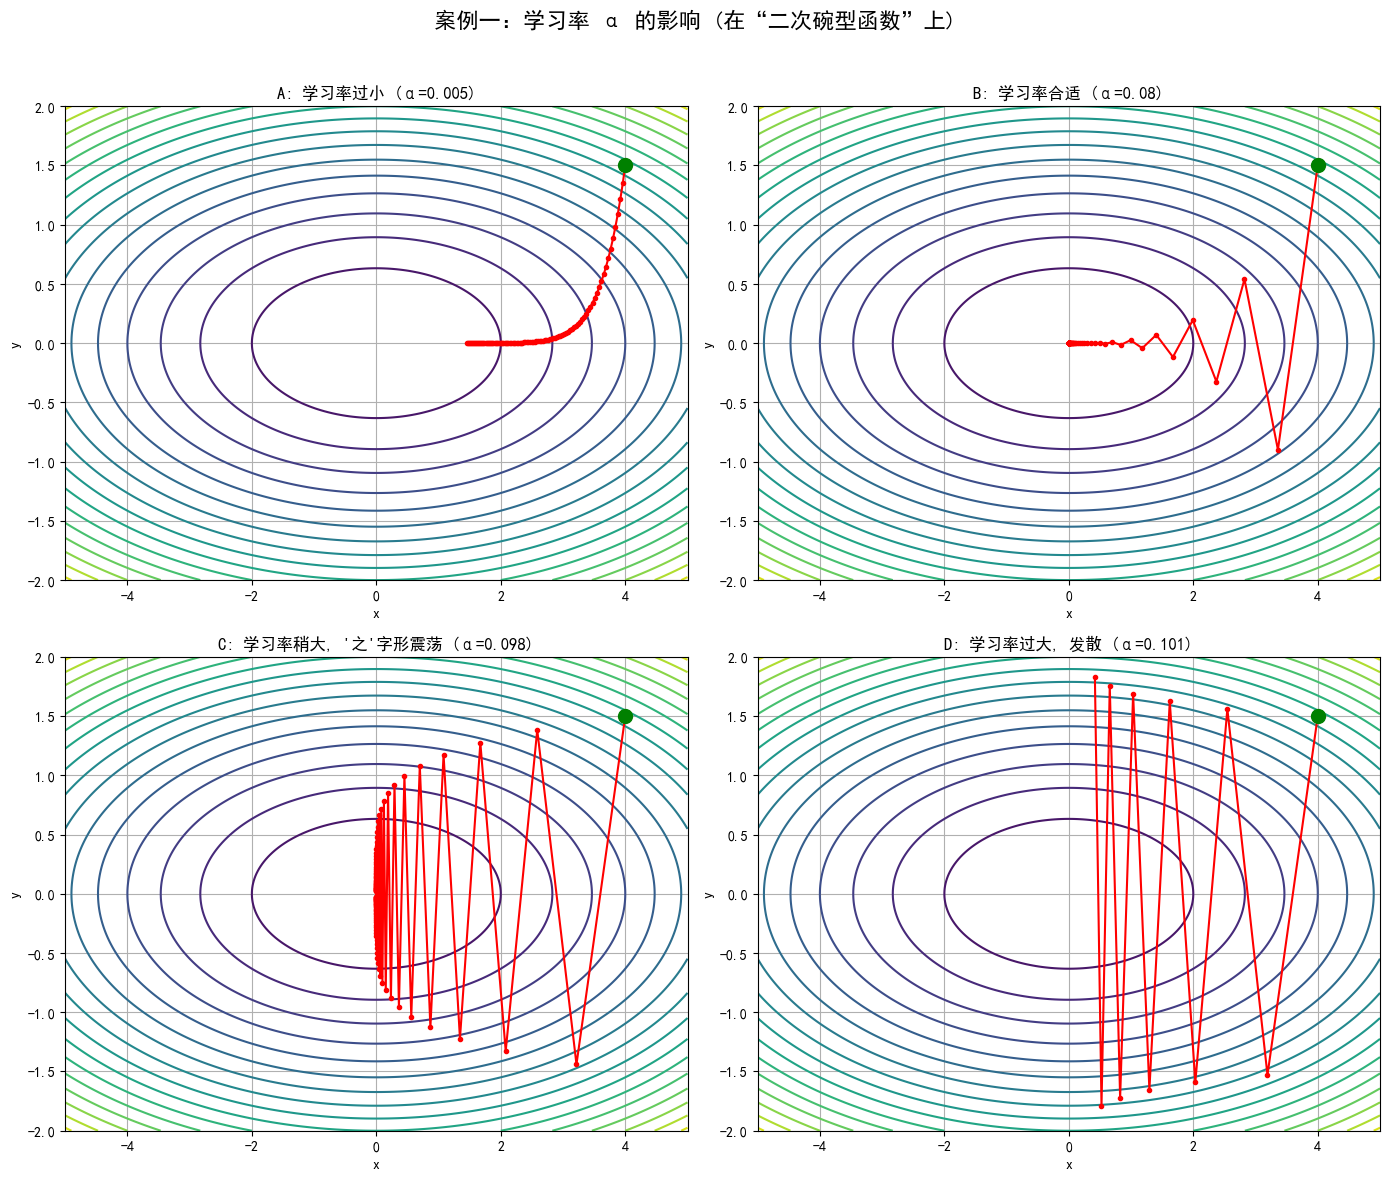

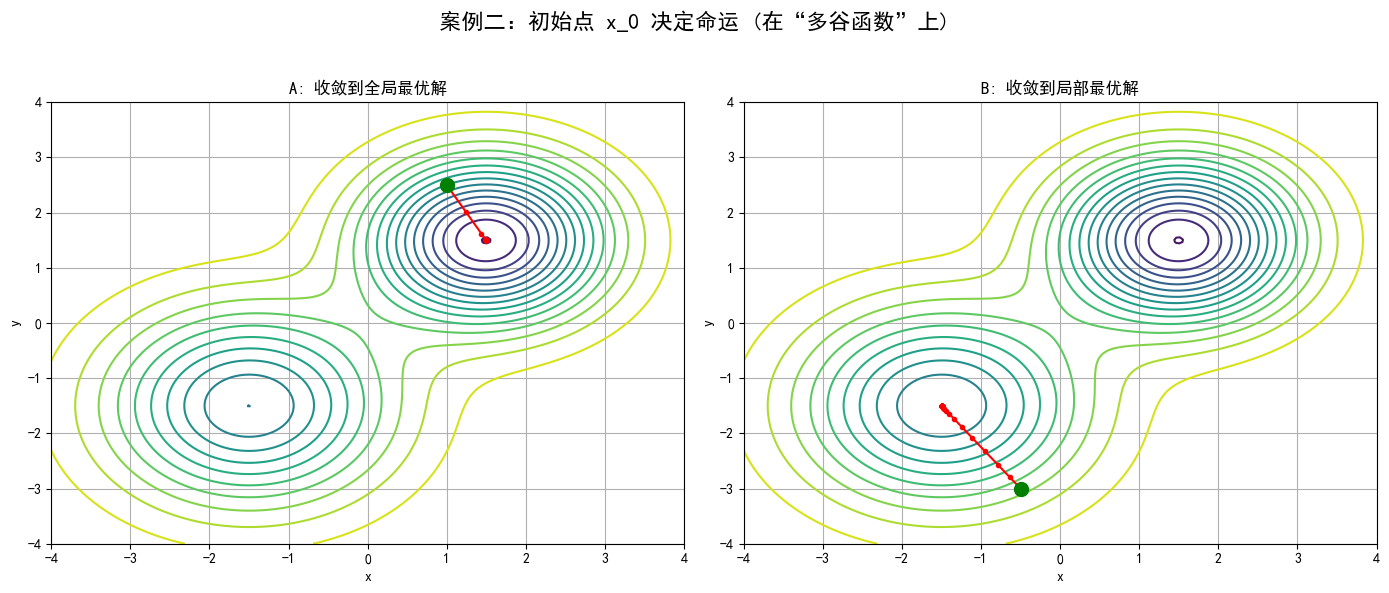

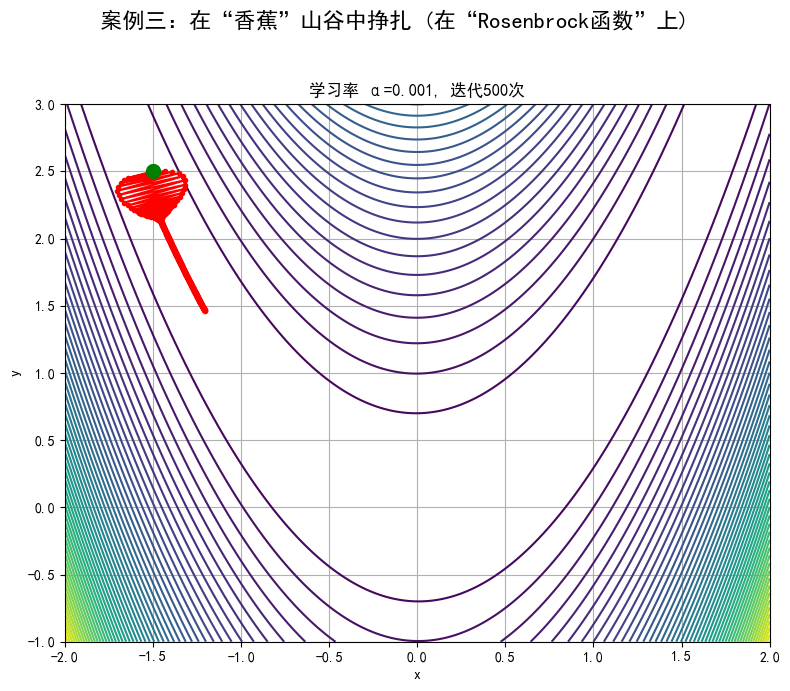

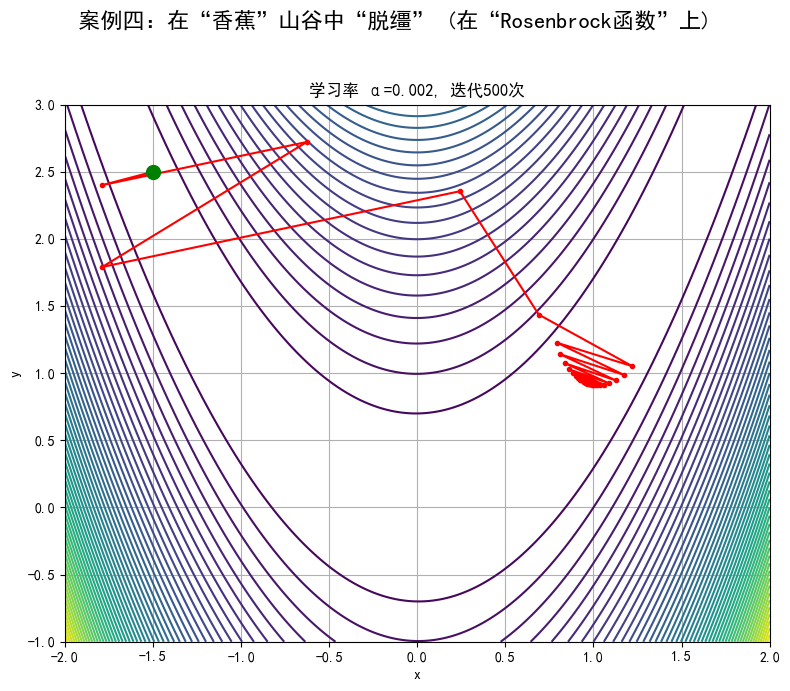

In [3]:
# --- 模块二：预设案例分析 ---
def plot_preset_cases(fig, ax, func_info, start_point, learning_rate, iterations, title):
    func, grad_func, x_range, y_range = func_info["func"], func_info["grad"], func_info["x_range"], func_info["y_range"]
    x = np.linspace(x_range[0], x_range[1], 200)
    y = np.linspace(y_range[0], y_range[1], 200)
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)
    path = run_gradient_descent(grad_func, start_point, learning_rate, iterations)
    ax.contour(X, Y, Z, levels=func_info["levels"], cmap='viridis')
    ax.plot(path[:, 0], path[:, 1], '-o', color='red', markersize=3)
    ax.plot(start_point[0], start_point[1], 'go', markersize=10)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True)
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)

fig1, axes1 = plt.subplots(2, 2, figsize=(14, 12))
fig1.suptitle('案例一：学习率 α 的影响 (在“二次碗型函数”上)', fontsize=16)
bowl_info = functions["二次碗型函数"]
start_pt_bowl = (4, 1.5)
plot_preset_cases(fig1, axes1[0, 0], bowl_info, start_pt_bowl, 0.005, 100, "A: 学习率过小 (α=0.005)")
plot_preset_cases(fig1, axes1[0, 1], bowl_info, start_pt_bowl, 0.08, 100, "B: 学习率合适 (α=0.08)")
plot_preset_cases(fig1, axes1[1, 0], bowl_info, start_pt_bowl, 0.098, 100, "C: 学习率稍大, '之'字形震荡 (α=0.098)")
plot_preset_cases(fig1, axes1[1, 1], bowl_info, start_pt_bowl, 0.101, 10, "D: 学习率过大, 发散 (α=0.101)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle('案例二：初始点 x_0 决定命运 (在“多谷函数”上)', fontsize=16)
multi_info = functions["多谷函数"]
plot_preset_cases(fig2, axes2[0], multi_info, (1.0, 2.5), 0.3, 50, "A: 收敛到全局最优解")
plot_preset_cases(fig2, axes2[1], multi_info, (-0.5, -3.0), 0.3, 50, "B: 收敛到局部最优解")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig3, ax3 = plt.subplots(figsize=(8, 7))
fig3.suptitle('案例三：在“香蕉”山谷中挣扎 (在“Rosenbrock函数”上)', fontsize=16)
rosen_info = functions["Rosenbrock函数"]
plot_preset_cases(fig3, ax3, rosen_info, (-1.5, 2.5), 0.001, 500, "学习率 α=0.001, 迭代500次") # 增加了迭代次数以观察更多细节
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig3, ax3 = plt.subplots(figsize=(8, 7))
fig3.suptitle('案例四：在“香蕉”山谷中“脱缰” (在“Rosenbrock函数”上)', fontsize=16)
rosen_info = functions["Rosenbrock函数"]
plot_preset_cases(fig3, ax3, rosen_info, (-1.5, 2.5), 0.002, 500, "学习率 α=0.002, 迭代500次") # 增加了迭代次数以观察更多细节
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()